In [1]:
# Packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot
import numpy as np
import pandas as pd
import seaborn
import sys
# Open flood_tool package
sys.path.append('../..')
import flood_tool as ft
# Open functions from geo.py
sys.path.append('..')
from geo import get_gps_lat_long_from_easting_northing
from geo import get_easting_northing_from_gps_lat_long

## Opening Dataset

In [2]:
# Open dataset
DF_orig = pd.read_csv("../resources/stations.csv")
DF_orig

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow
0,000008,Rainfall station,53.480556,-1.441674,NaN,NaN,NaN,NaN
1,000028,Rainfall station,53.500289,-1.673575,NaN,NaN,NaN,NaN
2,000075TP,Rainfall station,51.084022,-0.214597,NaN,NaN,NaN,NaN
3,000076TP,Rainfall station,51.701508,-0.747539,NaN,NaN,NaN,NaN
4,000180TP,Rainfall station,51.618838,0.173236,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2021,E71839,Portsmouth,50.802280,-1.111170,NaN,NaN,NaN,NaN
2022,E71939,Bournemouth,50.714331,-1.874873,NaN,NaN,NaN,NaN
2023,E70739,Aberdeen,57.144060,-2.077360,NaN,NaN,NaN,NaN
2024,E74239,Tobermory,56.623110,-6.064220,NaN,NaN,NaN,NaN


In [3]:
# Calculate percentage of missing values in each column
missing = DF_orig.isnull().sum() / len(DF_orig)
missing

stationReference    0.000000
stationName         0.001974
latitude            0.004936
longitude           0.004936
maxOnRecord         0.524679
minOnRecord         0.525666
typicalRangeHigh    0.525666
typicalRangeLow     0.525666
dtype: float64

In [4]:
# List water level variables
level_vars = ['maxOnRecord', 'minOnRecord', 'typicalRangeHigh', 'typicalRangeLow']

## Converting Coordinates

In [5]:
# Convert coordinates from longitude and longitude to easting and northing
def Convert_Coords(DF_orig):
    DF = DF_orig.copy()
# Get longitude latitude coordinates
    eastings, northings = get_easting_northing_from_gps_lat_long(DF_orig['latitude'], DF_orig['longitude'])
# Add latitude longitude coordinates into dataframe
    DF['easting'] = eastings
    DF['northing'] = northings
    return (DF)
# Apply function
DF_V1 = Convert_Coords(DF_orig)
DF_V1

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing
0,000008,Rainfall station,53.480556,-1.441674,NaN,NaN,NaN,NaN,437150.512108,398348.710960
1,000028,Rainfall station,53.500289,-1.673575,NaN,NaN,NaN,NaN,421750.534631,400448.642470
2,000075TP,Rainfall station,51.084022,-0.214597,NaN,NaN,NaN,NaN,525150.530744,133149.574480
3,000076TP,Rainfall station,51.701508,-0.747539,NaN,NaN,NaN,NaN,486650.531968,201049.405434
4,000180TP,Rainfall station,51.618838,0.173236,NaN,NaN,NaN,NaN,550550.534797,193349.379816
...,...,...,...,...,...,...,...,...,...,...
2021,E71839,Portsmouth,50.802280,-1.111170,NaN,NaN,NaN,NaN,462731.265440,100678.719642
2022,E71939,Bournemouth,50.714331,-1.874873,NaN,NaN,NaN,NaN,408930.528896,90529.727335
2023,E70739,Aberdeen,57.144060,-2.077360,NaN,NaN,NaN,NaN,395417.582934,805910.170180
2024,E74239,Tobermory,56.623110,-6.064220,NaN,NaN,NaN,NaN,150790.793963,755306.935288


## Seperating Dataset Into Rainfall and Water Level Stations

In [6]:
# Seperate dataset into rainfall stations and water level stations
DF_rainfall = DF_V1[DF_V1['stationName'] == 'Rainfall station']
DF_rainfall = DF_rainfall.drop(columns=level_vars)
DF_level = DF_V1[DF_V1['stationName'] != 'Rainfall station']
# Drop rows with no latitude longitude values
DF_rainfall = DF_rainfall.dropna(subset=['latitude', 'longitude']).reset_index().drop(columns='index')
DF_level = DF_level.dropna(subset=['latitude', 'longitude']).reset_index().drop(columns='index')

In [7]:
DF_rainfall

,stationReference,stationName,latitude,longitude,easting,northing
0,000008,Rainfall station,53.480556,-1.441674,437150.512108,398348.710960
1,000028,Rainfall station,53.500289,-1.673575,421750.534631,400448.642470
2,000075TP,Rainfall station,51.084022,-0.214597,525150.530744,133149.574480
3,000076TP,Rainfall station,51.701508,-0.747539,486650.531968,201049.405434
4,000180TP,Rainfall station,51.618838,0.173236,550550.534797,193349.379816
...,...,...,...,...,...,...
893,E9660,Rainfall station,50.929364,-0.469557,507650.524814,115549.681959
894,E9720,Rainfall station,50.860296,-0.483186,506850.555277,107849.746269
895,EdgeH1,Rainfall station,53.560463,-2.873303,342250.520990,407448.681306
896,Mitch1,Rainfall station,53.742978,-2.323663,378750.549990,427448.620744


In [8]:
DF_level

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing
0,0130TH,Ewen,51.674733,-1.990400,0.945,-0.948,0.990,0.000,400760.571730,197329.368192
1,0144TH,Somerford Keynes,51.650724,-1.973061,1.484,0.325,1.600,0.363,401960.521598,194659.389917
2,0155TH,Oaksey,51.632205,-2.007169,1.887,-0.242,1.311,0.000,399600.530564,192599.408981
3,0184TH,Purton Stoke,51.613220,-1.874040,2.340,0.481,1.890,0.504,408818.519005,190495.374247
4,0190TH,Cricklade,51.646694,-1.865536,0.992,0.012,1.083,0.058,409400.521612,194219.366226
...,...,...,...,...,...,...,...,...,...,...
1113,E71839,Portsmouth,50.802280,-1.111170,NaN,NaN,NaN,NaN,462731.265440,100678.719642
1114,E71939,Bournemouth,50.714331,-1.874873,NaN,NaN,NaN,NaN,408930.528896,90529.727335
1115,E70739,Aberdeen,57.144060,-2.077360,NaN,NaN,NaN,NaN,395417.582934,805910.170180
1116,E74239,Tobermory,56.623110,-6.064220,NaN,NaN,NaN,NaN,150790.793963,755306.935288


## Data Cleaning

In [9]:
# Drop rows with missing water level records
DF_updated = DF_level.dropna(axis=0).reset_index().drop(columns='index')
DF_updated

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing
0,0130TH,Ewen,51.674733,-1.990400,0.945,-0.948,0.990,0.000,400760.571730,197329.368192
1,0144TH,Somerford Keynes,51.650724,-1.973061,1.484,0.325,1.600,0.363,401960.521598,194659.389917
2,0155TH,Oaksey,51.632205,-2.007169,1.887,-0.242,1.311,0.000,399600.530564,192599.408981
3,0184TH,Purton Stoke,51.613220,-1.874040,2.340,0.481,1.890,0.504,408818.519005,190495.374247
4,0190TH,Cricklade,51.646694,-1.865536,0.992,0.012,1.083,0.058,409400.521612,194219.366226
...,...,...,...,...,...,...,...,...,...,...
956,E9920,Pulborough Swan Bridge,50.956335,-0.513508,4.783,0.000,3.713,0.669,504501.525825,118485.677038
957,E9941,Brewhurst Mill,51.069575,-0.509483,19.280,16.300,18.950,16.320,504529.578352,131083.610866
958,L2312,Park Bridge,54.408693,-2.177133,3.492,-0.100,2.500,0.000,388600.562626,501485.326805
959,L3211,Hessle,53.719075,-0.434087,3.854,0.419,3.000,0.689,503431.518725,425878.548227


In [10]:
# Statistics for water level stations
DF_updated.describe()

,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing
count,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000
mean,51.919907,-1.027823,2.478512,0.440262,1.587161,0.464559,467118.086547,225490.608204
std,0.686925,0.966353,3.763667,3.804022,1.971018,1.756246,66753.226673,76208.440826
min,50.390648,-4.050919,0.188000,-6.100000,0.042000,-0.600000,256418.518707,55946.901972
25%,51.411884,-1.735909,1.320000,0.000000,0.750000,0.061000,418099.567867,169199.468715
50%,51.773908,-0.966655,1.979000,0.055000,1.250000,0.151000,471490.553661,209829.343384
75%,52.399868,-0.281280,2.890000,0.302000,2.000000,0.454000,517900.544669,278872.105809
max,55.049407,1.570041,103.274000,102.723000,35.376000,34.690000,642082.542713,572798.189794


Theoretically, the four water level variables should have values in this order: minOnRecord < typicalRangeLow < typicalRangeHigh < maxOnRecord. However, there are some inconsistencies in this dataset:

In [11]:
# Check for data inconsistencies
DF_updated[DF_updated['minOnRecord'] > DF_updated['maxOnRecord']]

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing
373,2928TH,Chertsey Bourne,51.402823,-0.539779,2.165,13.320,1.06,0.400,501670.540651,168099.534435
755,E140,Maidstone,51.271553,0.518493,3.577,3.688,0.75,0.234,575777.580460,155501.567422
775,E1530,Summerford Bridge,51.107299,0.139866,3.756,38.981,2.70,0.019,549900.520887,136399.618949
889,E427,Allington Lock,51.295161,0.507204,1.624,3.337,0.50,0.070,574900.538782,158099.572503


In [12]:
# Check for data inconsistencies
DF_updated[DF_updated['typicalRangeLow'] > DF_updated['typicalRangeHigh']]

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing
256,2481TH,Sindlesham Mill,51.426522,-0.898188,1.454,0.052,0.56,1.19,476700.556326,170299.499635


In [13]:
# Check for data inconsistencies
len(DF_updated[DF_updated['maxOnRecord'] < DF_updated['typicalRangeHigh']])

97

In [14]:
# Check for data inconsistencies
len(DF_updated[DF_updated['minOnRecord'] > DF_updated['typicalRangeLow']])

49

If maxOnRecord is lower than typicalRangeHigh, maxOnRecord will be replaced by the typicalRangeHigh value. If minOnRecord is higher than typicalRangeLow, minOnRecord will be replaced by the typicalRangeLow value. Finally, if typicalRangeHigh is lower than typicalRangeLow, typicalRangeHigh will be replaced by the typicalRangeLow value.

In [15]:
# Clean inconsistent data
def Data_Cleaning(DF_orig):
    max_on_record = np.array(DF_orig['maxOnRecord'])
    min_on_record = np.array(DF_orig['minOnRecord'])
    typical_range_high = np.array(DF_orig['typicalRangeHigh'])
    for i in range(len(DF_orig)):
        if DF_orig['maxOnRecord'][i] < DF_orig['typicalRangeHigh'][i]:
            max_on_record[i] = DF_orig['typicalRangeHigh'][i]
        if DF_orig['minOnRecord'][i] > DF_orig['typicalRangeLow'][i]:
            min_on_record[i] = DF_orig['typicalRangeLow'][i]
        if DF_orig['typicalRangeHigh'][i] < DF_orig['typicalRangeLow'][i]:
            typical_range_high[i] = DF_orig['typicalRangeLow'][i]
    DF = DF_orig.copy()
    DF['maxOnRecord'] = max_on_record
    DF['minOnRecord'] = min_on_record
    DF['typicalRangeHigh'] = typical_range_high
    return (DF)
DF_cleaned = Data_Cleaning(DF_updated)
DF_cleaned

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing
0,0130TH,Ewen,51.674733,-1.990400,0.990,-0.948,0.990,0.000,400760.571730,197329.368192
1,0144TH,Somerford Keynes,51.650724,-1.973061,1.600,0.325,1.600,0.363,401960.521598,194659.389917
2,0155TH,Oaksey,51.632205,-2.007169,1.887,-0.242,1.311,0.000,399600.530564,192599.408981
3,0184TH,Purton Stoke,51.613220,-1.874040,2.340,0.481,1.890,0.504,408818.519005,190495.374247
4,0190TH,Cricklade,51.646694,-1.865536,1.083,0.012,1.083,0.058,409400.521612,194219.366226
...,...,...,...,...,...,...,...,...,...,...
956,E9920,Pulborough Swan Bridge,50.956335,-0.513508,4.783,0.000,3.713,0.669,504501.525825,118485.677038
957,E9941,Brewhurst Mill,51.069575,-0.509483,19.280,16.300,18.950,16.320,504529.578352,131083.610866
958,L2312,Park Bridge,54.408693,-2.177133,3.492,-0.100,2.500,0.000,388600.562626,501485.326805
959,L3211,Hessle,53.719075,-0.434087,3.854,0.419,3.000,0.689,503431.518725,425878.548227


In [16]:
# Verify data is now consistent
DF_cleaned[DF_cleaned['maxOnRecord'] < DF_cleaned['typicalRangeHigh']]

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing


In [17]:
# Verify data is now consistent
DF_cleaned[DF_cleaned['minOnRecord'] > DF_cleaned['typicalRangeLow']]

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing


In [18]:
# Verify data is now consistent
DF_cleaned[DF_cleaned['typicalRangeLow'] > DF_cleaned['typicalRangeHigh']]

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing


In [19]:
# Verify data is now consistent
DF_cleaned[DF_cleaned['minOnRecord'] > DF_cleaned['maxOnRecord']]

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing


## Plotting Data

Text(0.5, 1.0, 'Box Plots')

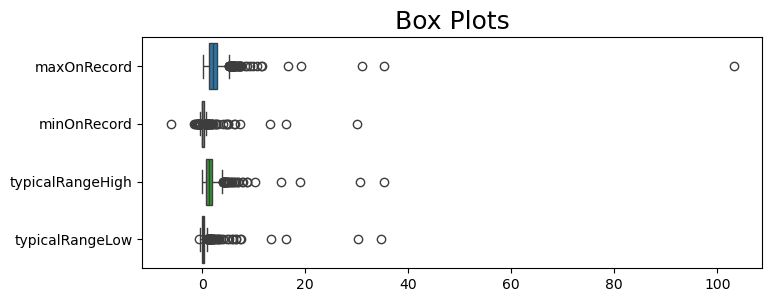

In [34]:
# Plot box plots for each numerical feature
Fig = pyplot.figure(figsize=(8,3))
seaborn.boxplot(data=DF_cleaned[level_vars], orient='h')
pyplot.title('Box Plots', fontsize=18)

In [21]:
# Function For Creating Cumulative Distribution
def Cumu_Dist(DF, Var, Min, Max, Bin_Width):
    Values = np.arange(Min, Max+Bin_Width, Bin_Width)
    Count = np.zeros(len(Values))
    for i in range(len(Count)):
        Range = DF[(DF[Var] >= Min) & (DF[Var] <= Values[i])]
        Count[i] = len(Range)
    Density = Count / len(DF[Var])
    return (Values, Density)

In [22]:
# Function For Creating Cumulative Distribution
def Prob_Dist(DF, Var, Min, Max, Bin_Width):
    Values = np.arange(Min, Max+Bin_Width, Bin_Width)
    Count = np.zeros(len(Values))
    for i in range(len(Count)):
        Range = DF[(DF[Var] >= Values[i]-0.5*Bin_Width) & (DF[Var] < Values[i]+0.5*Bin_Width)]
        Count[i] = len(Range)
    Density = Count / len(DF[Var])
    return (Values, Density)

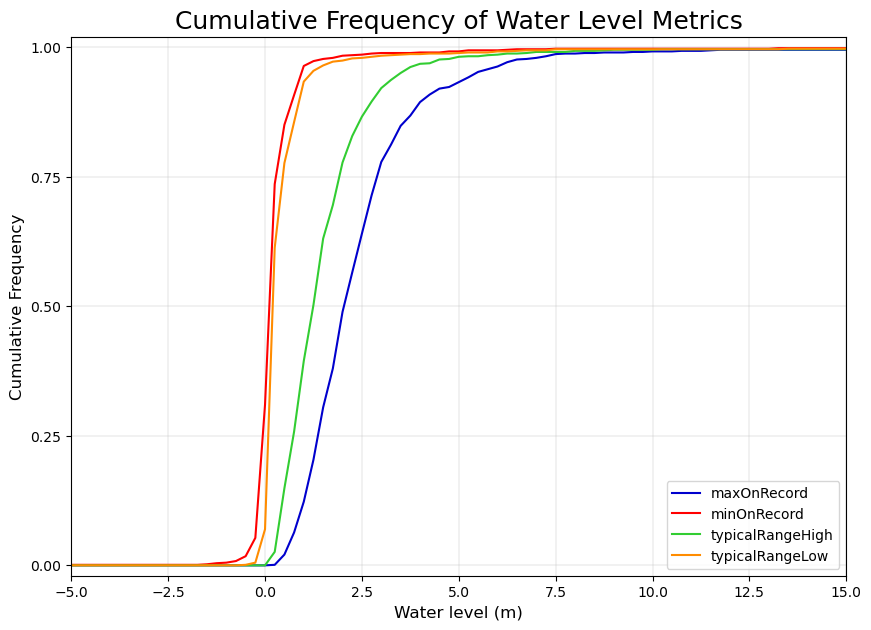

In [23]:
# Plot cumulative frequency distribution
Fig = pyplot.figure(figsize=(10,7))
Axis = Fig.add_subplot(1,1,1)
colours = ['mediumblue', 'red', 'limegreen', 'darkorange']
for i in range(len(level_vars)):
    Values, Density = Cumu_Dist(DF_cleaned, level_vars[i], -7, 104, 0.25)
    pyplot.plot(Values, Density, c=colours[i], label=level_vars[i])
# Formatting
pyplot.xlim(-5,15)
pyplot.ylim(-0.02,1.02)
pyplot.xticks(np.arange(-5,17.5,2.5))
pyplot.yticks(np.arange(0,1.25,0.25))
pyplot.xlabel('Water level (m)', fontsize=12)
pyplot.ylabel('Cumulative Frequency', fontsize=12)
pyplot.title('Cumulative Frequency of Water Level Metrics', fontsize=18)
pyplot.grid(linewidth=0.3, color='silver', linestyle='-')
pyplot.legend(loc=4)
pyplot.show()

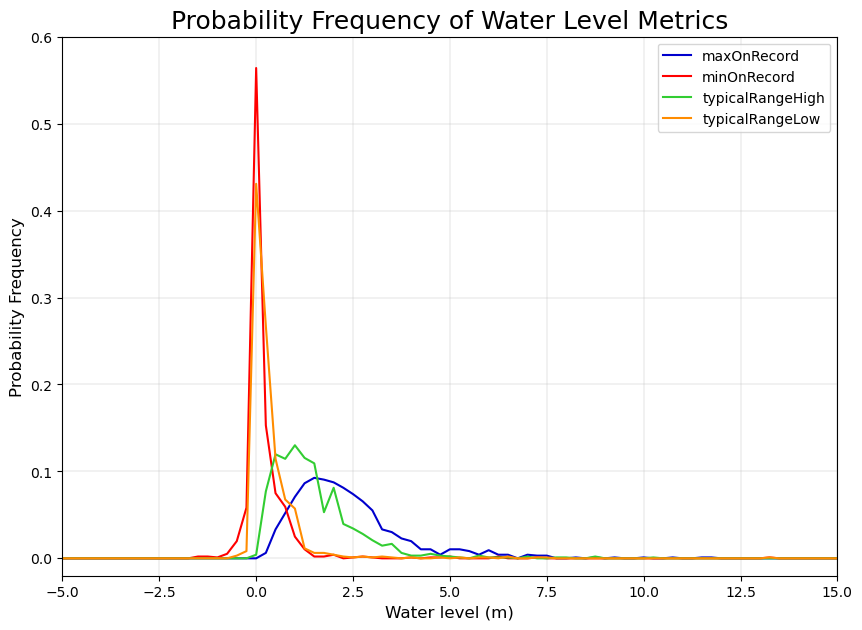

In [24]:
# Plot probability frequency distribution
Fig = pyplot.figure(figsize=(10,7))
Axis = Fig.add_subplot(1,1,1)
colours = ['mediumblue', 'red', 'limegreen', 'darkorange']
for i in range(len(level_vars)):
    Values, Density = Prob_Dist(DF_cleaned, level_vars[i], -7, 104, 0.25)
    pyplot.plot(Values, Density, c=colours[i], label=level_vars[i])
# Formatting
pyplot.xlim(-5,15)
pyplot.ylim(-0.02,0.6)
pyplot.xticks(np.arange(-5,17.5,2.5))
pyplot.yticks(np.arange(0,0.7,0.1))
pyplot.xlabel('Water level (m)', fontsize=12)
pyplot.ylabel('Probability Frequency', fontsize=12)
pyplot.title('Probability Frequency of Water Level Metrics', fontsize=18)
pyplot.grid(linewidth=0.3, color='silver', linestyle='-')
pyplot.legend(loc=1)
pyplot.show()

/opt/anaconda3/envs/Kinen/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Kinen/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


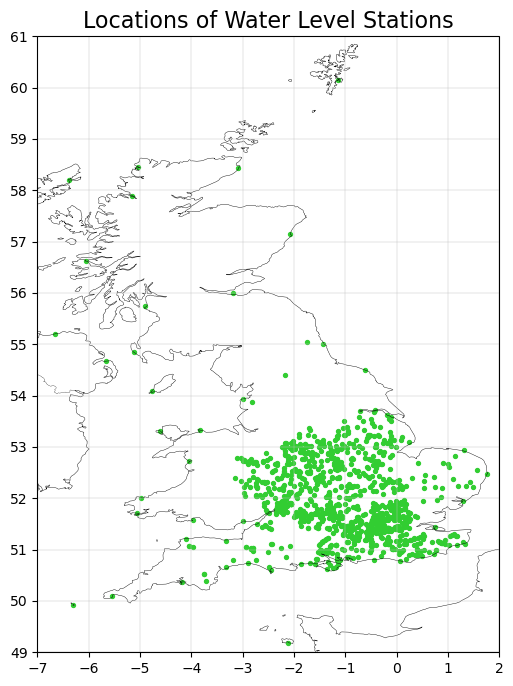

In [25]:
# Plot map of water level stations
Fig = pyplot.figure(figsize=(6,8))
# Add coastlines and borders
Axis = Fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
Axis.coastlines(linewidth=0.3)
Axis.add_feature(cfeature.BORDERS, linewidth=0.2)
# Plot stations
pyplot.scatter(DF_level['longitude'], DF_level['latitude'], c='limegreen', s=8)
# Formatting
x_Axis = np.arange(-7, 3, 1)
y_Axis = np.arange(49, 62, 1)
Axis.set_xlim(-7,2)
Axis.set_ylim(49,61)
Axis.set_xticks(x_Axis)
Axis.set_yticks(y_Axis)
Axis.set_title('Locations of Water Level Stations', fontsize=16)
Gridline = Axis.grid(linewidth=0.3, color='silver', linestyle='-')
pyplot.show()

/opt/anaconda3/envs/Kinen/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Kinen/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


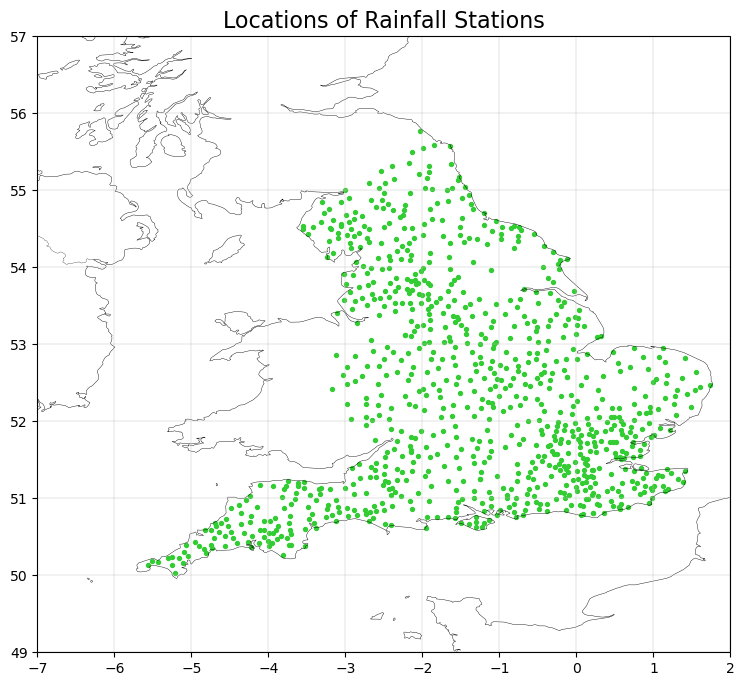

In [26]:
# Plot map of rainfall stations
Fig = pyplot.figure(figsize=(9,8))
# Add coastlines and borders
Axis = Fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
Axis.coastlines(linewidth=0.3)
Axis.add_feature(cfeature.BORDERS, linewidth=0.2)
# Plot stations
pyplot.scatter(DF_rainfall['longitude'], DF_rainfall['latitude'], c='limegreen', s=8)
# Formatting
x_Axis = np.arange(-7, 3, 1)
y_Axis = np.arange(49, 58, 1)
Axis.set_xlim(-7,2)
Axis.set_ylim(49,57)
Axis.set_xticks(x_Axis)
Axis.set_yticks(y_Axis)
Axis.set_title('Locations of Rainfall Stations', fontsize=16)
Gridline = Axis.grid(linewidth=0.3, color='silver', linestyle='-')
pyplot.show()

## Imputing Missing Values

In [27]:
# Calculate median for each water level metric
medians = {}
for var in level_vars:
    medians[var] = np.median(DF_cleaned[var])
medians

{'maxOnRecord': np.float64(2.066),
 'minOnRecord': np.float64(0.05),
 'typicalRangeHigh': np.float64(1.25),
 'typicalRangeLow': np.float64(0.151)}

In [28]:
# Impute missing values using the median for each water level metric
def Impute_Missing(DF_orig, medians):
    DF = DF_orig.copy()
    for var in level_vars:
        median = medians[var]
        DF[var] = DF_orig[var].fillna(median)
    return (DF)
DF_imputed = Impute_Missing(DF_level, medians)
DF_imputed

,stationReference,stationName,latitude,longitude,maxOnRecord,minOnRecord,typicalRangeHigh,typicalRangeLow,easting,northing
0,0130TH,Ewen,51.674733,-1.990400,0.945,-0.948,0.990,0.000,400760.571730,197329.368192
1,0144TH,Somerford Keynes,51.650724,-1.973061,1.484,0.325,1.600,0.363,401960.521598,194659.389917
2,0155TH,Oaksey,51.632205,-2.007169,1.887,-0.242,1.311,0.000,399600.530564,192599.408981
3,0184TH,Purton Stoke,51.613220,-1.874040,2.340,0.481,1.890,0.504,408818.519005,190495.374247
4,0190TH,Cricklade,51.646694,-1.865536,0.992,0.012,1.083,0.058,409400.521612,194219.366226
...,...,...,...,...,...,...,...,...,...,...
1113,E71839,Portsmouth,50.802280,-1.111170,2.066,0.050,1.250,0.151,462731.265440,100678.719642
1114,E71939,Bournemouth,50.714331,-1.874873,2.066,0.050,1.250,0.151,408930.528896,90529.727335
1115,E70739,Aberdeen,57.144060,-2.077360,2.066,0.050,1.250,0.151,395417.582934,805910.170180
1116,E74239,Tobermory,56.623110,-6.064220,2.066,0.050,1.250,0.151,150790.793963,755306.935288


## Outputting Preprocessed Data

In [29]:
# Define output directory
Output_Diri = '../resources/preprocessed_data/'

In [30]:
# Create new csv file with water level stations data (with imputing missing values)
DF_imputed.to_csv(Output_Diri+'level_stations_imputed.csv', index=False)

In [31]:
# Create new csv file with water level stations data (no imputing missing values)
DF_cleaned.to_csv(Output_Diri+'level_stations_no_impute.csv', index=False)

In [32]:
# Create new csv file with rainfall stations data
DF_rainfall.to_csv(Output_Diri+'rainfall_stations.csv', index=False)